# 11 — Relabel ward / district / region for the 500m sub-cells

The current `ward_name` / `district` / `region` on the selected sub-cells are **wrong for controls**: they were assigned by a *nearest-treatment-village* join upstream (in `grid_500m_5km_ID.shp`), so e.g. "Barikiwa" got smeared across control cells up to ~200 km apart.

This notebook fixes the labels by a **point-in-polygon spatial join** of each sub-cell centroid against an authoritative TZ admin-3 (ward) polygon layer — giving the correct **ward (ADM3), district (ADM2), region (ADM1)** for every 500m sub-cell.

**Safety:** this does NOT resample. We load the frozen 110 selected sub-cells, overwrite only the label columns, and assert the `grid_id` set is unchanged. The export cell is guarded (`WRITE=False`) and backs up the original first.

## Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import geopandas as gpd
import pandas as pd
import numpy as np

from src.utils.config_loader import load_config, get_data_dir

config = load_config()
data_dir = get_data_dir(config)
boundaries = data_dir / '01_input_data' / 'boundaries'

SELECTED   = boundaries / 'selected_subcells_500m.gpkg'
WARD_LAYER = boundaries / 'TZ_wards' / 'tza_admbnda_adm3_20181019.shp'   # OCHA TZ admin-3 polygons

print('selected exists: ', SELECTED.exists())
print('ward layer exists:', WARD_LAYER.exists())

Loaded local config overrides from config.local.yaml
selected exists:  True
ward layer exists: True


## 1. Load the frozen 110 selected sub-cells

Keep the original labels as `*_old` for QA. Snapshot the `grid_id`s to prove sampling is untouched.

In [2]:
sub = gpd.read_file(SELECTED)
print(f'Loaded {len(sub)} selected sub-cells | CRS {sub.crs}')

for c in ['ward_name', 'district', 'region']:
    if c in sub.columns:
        sub[f'{c}_old'] = sub[c]

GRID_IDS_BEFORE = set(sub['grid_id'])
N_BEFORE = len(sub)

print('\ncurrent (suspect) ward_name counts:')
print(sub['ward_name'].value_counts(dropna=False).head(15))
sub[['grid_id', '5km_id', 'selection_role', 'sample_status', 'ward_name', 'district', 'region']].head(10)

Loaded 110 selected sub-cells | CRS EPSG:32736

current (suspect) ward_name counts:
ward_name
Mkutano          20
Mpigamiti         5
Lilombe           5
Ruhembe           4
Bwakira Chini     4
Mlembwe           4
Barikiwa          4
Ruvu Remit        3
Naberera          3
Selembala         3
Mikese            3
Nandembo          3
Singisa           2
Mang'ula 'B'      2
Kilangali         2
Name: count, dtype: int64


,grid_id,5km_id,selection_role,sample_status,ward_name,district,region
0,G_0588_0987,10758.0,primary,sampled,Rudewa,Kilosa,Morogoro
1,G_0587_0987,10758.0,primary,sampled,Chanzuru,Kilosa,Morogoro
2,G_0586_0964,10760.0,primary,replacement,Kilangali,Kilosa,Morogoro
3,G_0586_0965,10760.0,primary,replacement,Kilangali,Kilosa,Morogoro
4,G_0587_0964,10760.0,reserve,replacement,Tindiga,Kilosa,Morogoro
5,G_0583_0953,10761.0,primary,replacement,Ruhembe,Kilosa,Morogoro
6,G_0583_0951,10761.0,primary,replacement,Ruhembe,Kilosa,Morogoro
7,G_0583_0950,10761.0,reserve,replacement,Ruhembe,Kilosa,Morogoro
8,G_0583_0952,10761.0,reserve,replacement,Ruhembe,Kilosa,Morogoro
9,G_0582_0943,10762.0,primary,sampled,Mang'ula 'B',Kilombero,Morogoro


## 2. Load the TZ admin-3 ward polygons

Guard that it's actually polygons, and map OCHA columns: `ADM1_EN`->region, `ADM2_EN`->district, `ADM3_EN`->ward.

Index(['ET_ID', 'ADM0_EN', 'ADM0_SW', 'ADM0_PCODE', 'ADM1_EN', 'ADM1_PCODE',
       'ADM2_EN', 'ADM2_PCODE', 'ADM3_EN', 'ADM3_PCODE', 'geometry'],
      dtype='object')
Ward polygons: 3643 | regions 31 | districts 170 | wards 3385
CRS: EPSG:4326
kept columns: ['ET_ID', 'ADM0_EN', 'ADM0_SW', 'ADM0_PCODE', 'ADM1_EN', 'ADM1_PCODE', 'ADM2_EN', 'ADM2_PCODE', 'ADM3_EN', 'ADM3_PCODE', 'geometry', 'region_new', 'district_new', 'ward_new']


,ET_ID,ADM0_EN,ADM0_SW,ADM0_PCODE,ADM1_EN,ADM1_PCODE,ADM2_EN,ADM2_PCODE,ADM3_EN,ADM3_PCODE,geometry,region_new,district_new,ward_new
0,0,United Republic of Tanzania,Jamhuri ya Muungano wa Tanzania,TZ,Dodoma,TZ01,Kondoa,TZ0101,Bumbuta,TZ0101011,"POLYGON ((35.93715 -4.59737, 35.93632 -4.59956...",Dodoma,Kondoa,Bumbuta
1,1,United Republic of Tanzania,Jamhuri ya Muungano wa Tanzania,TZ,Dodoma,TZ01,Kondoa,TZ0101,Pahi,TZ0101021,"POLYGON ((35.93456 -4.61214, 35.93301 -4.61637...",Dodoma,Kondoa,Pahi
2,2,United Republic of Tanzania,Jamhuri ya Muungano wa Tanzania,TZ,Dodoma,TZ01,Kondoa,TZ0101,Haubi,TZ0101041,"POLYGON ((35.92014 -4.74797, 35.92617 -4.74806...",Dodoma,Kondoa,Haubi
3,3,United Republic of Tanzania,Jamhuri ya Muungano wa Tanzania,TZ,Dodoma,TZ01,Kondoa,TZ0101,Kalamba,TZ0101051,"POLYGON ((35.88398 -4.78581, 35.88743 -4.78581...",Dodoma,Kondoa,Kalamba
4,4,United Republic of Tanzania,Jamhuri ya Muungano wa Tanzania,TZ,Dodoma,TZ01,Kondoa,TZ0101,Kwadelo,TZ0101061,"POLYGON ((36.33663 -4.84585, 36.33696 -4.84824...",Dodoma,Kondoa,Kwadelo


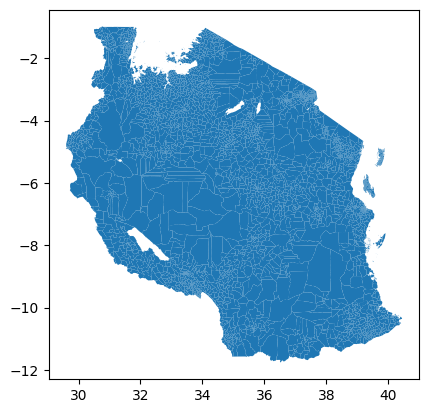

In [3]:
wards = gpd.read_file(WARD_LAYER)
print(wards.columns)
assert set(wards.geom_type.unique()) <= {'Polygon', 'MultiPolygon'}, \
    f'Ward layer must be polygons, got {wards.geom_type.unique()} (the admbndl zip is LINES - use admbnda)'

# Add our working column names as COPIES (not rename), so the original
# ADM0_EN / ADM1_EN / ADM2_EN / ADM3_EN / *_PCODE columns are all kept too.
wards['region_new']   = wards['ADM1_EN']
wards['district_new'] = wards['ADM2_EN']
wards['ward_new']     = wards['ADM3_EN']

print(f'Ward polygons: {len(wards)} | regions {wards.region_new.nunique()} | '
      f'districts {wards.district_new.nunique()} | wards {wards.ward_new.nunique()}')
print('CRS:', wards.crs)
print('kept columns:', list(wards.columns))
wards.plot()
wards.head()

## 3. Point-in-polygon join (one ward per sub-cell)

Join each sub-cell **centroid** to the ward polygon that contains it (in UTM 36S for accuracy). Any centroid that falls outside every polygon (border slivers) is filled from the **nearest** ward and flagged for review.

In [4]:
UTM = 32736

# --- CRS check: reproject BOTH layers to the same metric CRS before the join ---
print('sub CRS:', sub.crs, '| wards CRS:', wards.crs)
assert sub.crs is not None and wards.crs is not None, 'both layers need a defined CRS for reprojection'

sub_utm = sub.to_crs(UTM)
wards_utm = wards.to_crs(UTM)

pts = sub_utm.copy()
pts['geometry'] = sub_utm.geometry.centroid

joined = gpd.sjoin(pts, wards_utm, how='left', predicate='within')
joined = joined[~joined.index.duplicated(keep='first')]   # guard against border multi-matches

missing = joined['ward_new'].isna()
print(f'matched within a ward polygon: {(~missing).sum()} / {len(sub)} | unmatched: {int(missing.sum())}')

joined['ward_match'] = 'within'
if missing.any():
    nn = gpd.sjoin_nearest(pts[missing], wards_utm, how='left')
    nn = nn[~nn.index.duplicated(keep='first')]
    for col in ['region_new', 'district_new', 'ward_new', 'ADM3_PCODE']:
        joined.loc[missing, col] = nn[col]
    joined.loc[missing, 'ward_match'] = 'nearest (REVIEW)'
    print('  -> filled by nearest ward (review these):')
    print(joined.loc[missing, ['grid_id', '5km_id', 'ward_new']].to_string(index=False))

# Join results are plain string columns — `sub` geometry/CRS are never touched.
for col in ['region_new', 'district_new', 'ward_new', 'ADM3_PCODE', 'ward_match']:
    sub[col] = joined[col]

sub CRS: EPSG:32736 | wards CRS: EPSG:4326
matched within a ward polygon: 110 / 110 | unmatched: 0


## 4. QA — sampling untouched, Barikiwa fixed, old vs new

In [5]:
from itertools import combinations

# (a) sampling untouched
assert len(sub) == N_BEFORE, 'row count changed!'
assert set(sub['grid_id']) == GRID_IDS_BEFORE, 'grid_id set changed - sampling was altered!'
print(f'OK: still {len(sub)} sub-cells, identical grid_ids -> sampling untouched.')

# (b) Barikiwa: was one ward smeared ~200 km; what do the cells map to now?
bar = sub[sub['ward_name_old'].astype(str).str.contains('Barikiwa', case=False, na=False)]
print(f'\nCells previously labelled Barikiwa: {len(bar)}')
print('  NEW wards:    ', sorted(bar['ward_new'].dropna().unique().tolist()))
print('  NEW districts:', sorted(bar['district_new'].dropna().unique().tolist()))
print('  NEW regions:  ', sorted(bar['region_new'].dropna().unique().tolist()))

# (c) overall: how many labels changed
changed = (sub['ward_name_old'] != sub['ward_new']).sum()
print(f'\nward_name changed for {changed} / {len(sub)} sub-cells')

cmp = sub[['grid_id', '5km_id', 'ward_name_old', 'ward_new',
           'district_old', 'district_new', 'region_old', 'region_new', 'ward_match']]
cmp.head(25)

OK: still 110 sub-cells, identical grid_ids -> sampling untouched.

Cells previously labelled Barikiwa: 4
  NEW wards:     ['Chagongwe', 'Chanjale', 'Godegode']
  NEW districts: ['Gairo', 'Mpwapwa']
  NEW regions:   ['Dodoma', 'Morogoro']

ward_name changed for 110 / 110 sub-cells


,grid_id,5km_id,ward_name_old,ward_new,district_old,district_new,region_old,region_new,ward_match
0,G_0588_0987,10758.0,Rudewa,Ibumu,Kilosa,Kilolo,Morogoro,Iringa,within
1,G_0587_0987,10758.0,Chanzuru,Malenga Makali,Kilosa,Iringa,Morogoro,Iringa,within
2,G_0586_0964,10760.0,Kilangali,Ibumu,Kilosa,Kilolo,Morogoro,Iringa,within
3,G_0586_0965,10760.0,Kilangali,Ibumu,Kilosa,Kilolo,Morogoro,Iringa,within
4,G_0587_0964,10760.0,Tindiga,Ibumu,Kilosa,Kilolo,Morogoro,Iringa,within
5,G_0583_0953,10761.0,Ruhembe,Ibumu,Kilosa,Kilolo,Morogoro,Iringa,within
6,G_0583_0951,10761.0,Ruhembe,Ibumu,Kilosa,Kilolo,Morogoro,Iringa,within
7,G_0583_0950,10761.0,Ruhembe,Ibumu,Kilosa,Kilolo,Morogoro,Iringa,within
8,G_0583_0952,10761.0,Ruhembe,Ibumu,Kilosa,Kilolo,Morogoro,Iringa,within
9,G_0582_0943,10762.0,Mang'ula 'B',Ibumu,Kilombero,Kilolo,Morogoro,Iringa,within


## 4b. Overview of control-grid admin units (corrected labels)

Unique **region → district → ward** combinations across the 110 control sub-cells, using the corrected
`*_new` labels from the spatial join, with per-unit counts. Saved as a small CSV + XLSX for sharing.

In [6]:
SAVE_OVERVIEW = False

overview = (
    sub.groupby(['region_new', 'district_new', 'ward_new'], dropna=False)
       .agg(
           n_subcells=('grid_id', 'size'),
           n_5km_cells=('5km_id', 'nunique'),
           roles=('selection_role', lambda s: ', '.join(sorted(set(s.astype(str))))),
           sample_status=('sample_status', lambda s: ', '.join(sorted(set(s.astype(str))))),
           any_review=('ward_match', lambda s: bool((s == 'nearest (REVIEW)').any())),
       )
       .reset_index()
       .rename(columns={'region_new': 'region', 'district_new': 'district', 'ward_new': 'ward'})
       .sort_values(['region', 'district', 'ward'])
       .reset_index(drop=True)
)

print(f"Control grid spans: {overview['region'].nunique()} regions | "
      f"{overview['district'].nunique()} districts | {overview['ward'].nunique()} wards "
      f"({len(overview)} region/district/ward combos)")

if SAVE_OVERVIEW:
    ov_csv  = boundaries / 'control_grid_ward_overview.csv'
    ov_xlsx = boundaries / 'control_grid_ward_overview.xlsx'
    overview.to_csv(ov_csv, index=False)
    overview.to_excel(ov_xlsx, index=False, sheet_name='ward_overview')
    print('saved ->', ov_csv.name, '+', ov_xlsx.name, 'in', boundaries)

overview

Control grid spans: 3 regions | 6 districts | 20 wards (20 region/district/ward combos)


,region,district,ward,n_subcells,n_5km_cells,roles,sample_status,any_review
0,Dodoma,Kongwa,Chamkoroma,6,4,"primary, reserve",sampled,False
1,Dodoma,Kongwa,Nghumbi,7,3,"primary, reserve",sampled,False
2,Dodoma,Mpwapwa,Berege,4,1,"primary, reserve",sampled,False
3,Dodoma,Mpwapwa,Godegode,3,1,"primary, reserve",sampled,False
4,Dodoma,Mpwapwa,Gulwe,1,1,primary,sampled,False
5,Dodoma,Mpwapwa,Matomondo,3,3,primary,sampled,False
6,Dodoma,Mpwapwa,Mlunduzi,4,1,"primary, reserve",sampled,False
7,Dodoma,Mpwapwa,Wotta,4,1,"primary, reserve",sampled,False
8,Iringa,Iringa,Malenga Makali,1,1,primary,sampled,False
9,Iringa,Kilolo,Ibumu,10,4,"primary, reserve","replacement, sampled",False


## 4c. Map — selected 5km + 500m grid cells over the relevant (labeled) regions

Overlay the selected **5km control cells** and **500m sub-cells** on the **regions (ADM1)** they fall in
(dissolved from the ward layer, filtered to the control regions). Regions are labeled. Uses the corrected `region_new` labels.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
try:
    import contextily as cx
    HAVE_CX = True
except ImportError:
    HAVE_CX = False

# 5km control grid, filtered to the selected cells
cg = gpd.read_file(boundaries / 'control_grid_5km_flagged.gpkg')
sel_5km_ids = set(sub['5km_id'].dropna().astype(int))
cg_sel = cg[cg['id'].astype(int).isin(sel_5km_ids)].copy()

# Regions = ward layer dissolved to ADM1, kept only where our control cells fall
control_regions = set(sub['region_new'].dropna())
regions = wards.dissolve(by='region_new', as_index=False)[['region_new', 'geometry']]
regions_sel = regions[regions['region_new'].isin(control_regions)].copy()
print('control regions:', sorted(control_regions))

# Common CRS (Web Mercator) for an optional basemap
WM = 3857
regions_wm = regions_sel.to_crs(WM)
cg_wm = cg_sel.to_crs(WM)
sub_wm = sub.to_crs(WM)
sub_wm_pts = sub_wm.copy(); sub_wm_pts['geometry'] = sub_wm.geometry.centroid

fig, ax = plt.subplots(figsize=(13, 13))

# regions: light fill + outline
regions_wm.plot(ax=ax, column='region_new', cmap='Pastel2', alpha=0.30, edgecolor='black',
                linewidth=1.3, zorder=1)

# 5km selected control cells (outline)
cg_wm.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1.6, zorder=3)

# 500m selected sub-cells (true polygons) + centroid dots for visibility at this scale
role_colors = {'primary': '#22c55e', 'reserve': '#eab308'}
for role, c in role_colors.items():
    m = sub_wm['selection_role'] == role
    sub_wm[m].plot(ax=ax, facecolor=c, edgecolor=c, linewidth=0.5, zorder=4)
    sub_wm_pts[m].plot(ax=ax, color=c, markersize=18, edgecolor='black', linewidth=0.3, zorder=5)

# region labels at representative points
for _, r in regions_wm.iterrows():
    p = r.geometry.representative_point()
    ax.annotate(r['region_new'], (p.x, p.y), ha='center', va='center',
                fontsize=13, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7), zorder=6)

if HAVE_CX:
    try:
        cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
    except Exception as e:
        print('basemap skipped:', e)

handles = [
    mpatches.Patch(facecolor='none', edgecolor='black', label='Region (ADM1)'),
    mpatches.Patch(facecolor='none', edgecolor='red', label=f'Selected 5km control cells ({len(cg_sel)})'),
    mpatches.Patch(facecolor='#22c55e', label='500m primary'),
    mpatches.Patch(facecolor='#eab308', label='500m reserve'),
]
ax.legend(handles=handles, loc='lower left', fontsize=11, framealpha=0.9)
ax.set_title('Selected control grid (5km + 500m) over the relevant regions', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

NameError: name 'gpd' is not defined

## 5. Export (guarded)

Set `WRITE = True` to overwrite `selected_subcells_500m.gpkg` with corrected `ward_name` / `district` / `region` (plus a `ward_pcode`). The original is backed up first. QA helper columns are dropped on save.

> After writing, regenerate the downstream outputs (mbtiles / xlsx) so the corrected wards flow through — the layer folder names and the `samplegrids` index key on `ward_name`.

In [7]:
WRITE = True   # <-- set True to save

if WRITE:
    import datetime, shutil
    stamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    backup = SELECTED.with_name(f'selected_subcells_500m.backup_{stamp}.gpkg')
    shutil.copy2(SELECTED, backup)
    print('backed up original ->', backup.name)

    out = sub.copy()
    out['ward_name']  = out['ward_new']
    out['district']   = out['district_new']
    out['region']     = out['region_new']
    out['ward_pcode'] = out['ADM3_PCODE']
    drop = [c for c in out.columns if c.endswith('_old') or c.endswith('_new')
            or c in ('ward_match', 'ADM3_PCODE')]
    out = out.drop(columns=drop)

    # --- CRS guard: confirm the output CRS matches the original file before writing ---
    orig_crs = gpd.read_file(backup, rows=0).crs
    assert out.crs == orig_crs, f'output CRS {out.crs} != original {orig_crs}'
    print('writing CRS:', out.crs, '(matches original)')

    out.to_file(SELECTED, driver='GPKG')
    print(f'wrote {len(out)} sub-cells with corrected ward/district/region -> {SELECTED.name}')
else:
    print('WRITE=False - preview only. Set WRITE=True to save.')
    display(sub.head(20))

backed up original -> selected_subcells_500m.backup_20260618_160954.gpkg
writing CRS: EPSG:32736 (matches original)
wrote 110 sub-cells with corrected ward/district/region -> selected_subcells_500m.gpkg


## 6. Control-grid overview export

One row per selected 500m sub-cell with **grid id, sampled/replacement status, VCSL status, district, region**
(corrected labels). VCSL is merged in from the CCT flags (selected_subcells doesn't carry it). Saved as
`control_grid_overview.csv` + `.xlsx` in the `grid_info` deliverable folder.

In [28]:
from src.data_processing.load_boundaries import load_vcsl_flags, flag_vcsl_villages

# Read the (relabeled) selected sub-cells and merge the VCSL flag (attribute join on 5km id)
ov = gpd.read_file(SELECTED)
ov = flag_vcsl_villages(ov, load_vcsl_flags(Path(config['paths']['vcsl_flags'])), id_col='5km_id')
ov['vcsl_flagged'] = ov['vcsl_village'].notna().map({True: 'yes', False: 'no'})

overview_cols = ['grid_id', '5km_id', 'ward_name', 'district', 'region',
                 'sample_status', 'selection_role', 'vcsl_flagged', 'vcsl_village',
                 'building_count', 'latitude', 'longitude']
control_grid_overview = (
    ov.drop(columns='geometry')[overview_cols]
      .sort_values(['region', 'district', 'ward_name', 'grid_id'])
      .reset_index(drop=True)
)

GRID_INFO = Path(r'G:\Shared drives\TZ-CCT_RUBEV-0825\Data\0_Listing\1_Input\grid_info')
control_grid_overview.to_csv(GRID_INFO / 'control_grid_overview.csv', index=False)
control_grid_overview.to_excel(GRID_INFO / 'control_grid_overview.xlsx', index=False, sheet_name='control_grid')
print(f'wrote control_grid_overview.csv + .xlsx ({len(control_grid_overview)} rows) to {GRID_INFO}')
print('sample_status:', control_grid_overview.sample_status.value_counts().to_dict(),
      '| vcsl_flagged:', control_grid_overview.vcsl_flagged.value_counts().to_dict())
control_grid_overview

Loaded 905 VCSL flag records from G:\Shared drives\TZ-CCT_RUBEV-0825\Data\0_Listing\1_Input\grid_info\_temp\Sampled_control_pixels.gpkg (295 with a village label)
Flagged 24 / 110 cells with a VCSL village (5 distinct: Lumbiji, Malolo A, Malolo B, Mhowe, Msowero)
wrote control_grid_overview.csv + .xlsx (110 rows) to G:\Shared drives\TZ-CCT_RUBEV-0825\Data\0_Listing\1_Input\grid_info
sample_status: {'sampled': 97, 'replacement': 13} | vcsl_flagged: {'no': 86, 'yes': 24}


,grid_id,5km_id,ward_name,district,region,sample_status,selection_role,vcsl_flagged,vcsl_village,building_count,latitude,longitude
0,G_0712_1190,13129.0,Chamkoroma,Kongwa,Dodoma,sampled,primary,no,None,226,-6.384659,36.702948
1,G_0713_1188,13130.0,Chamkoroma,Kongwa,Dodoma,sampled,primary,no,None,34,-6.393654,36.707525
2,G_0713_1190,13129.0,Chamkoroma,Kongwa,Dodoma,sampled,primary,no,None,136,-6.384626,36.707460
3,G_0720_1194,13313.0,Chamkoroma,Kongwa,Dodoma,sampled,primary,no,None,23,-6.366344,36.738910
4,G_0721_1187,13314.0,Chamkoroma,Kongwa,Dodoma,sampled,reserve,no,None,35,-6.397905,36.743651
...,...,...,...,...,...,...,...,...,...,...,...,...
105,G_0812_1153,14973.0,Msowero,Kilosa,Morogoro,sampled,reserve,yes,Msowero,26,-6.548125,37.155364
106,G_0813_1151,14973.0,Msowero,Kilosa,Morogoro,sampled,primary,yes,Msowero,29,-6.557110,37.159949
107,G_0814_1151,14973.0,Msowero,Kilosa,Morogoro,sampled,primary,yes,Msowero,114,-6.557072,37.164460
108,G_0777_1150,14237.0,Rudewa,Kilosa,Morogoro,sampled,reserve,yes,Lumbiji,34,-6.562945,36.997581


In [8]:
##double check, now opening the selected subcells file again to confirm the ward/district/region columns are correct
subcells = gpd.read_file(SELECTED)


In [10]:
subcells.columns

Index(['grid_id', 'col', 'row', 'cell_size', 'ward_name', 'district', 'region',
       'is_treatme', 'is_program', 'is_adjacen', '5km_id', 'building_count',
       'mean_confidence', 'selection_role', 'sample_status', 'centroid_x',
       'centroid_y', 'latitude', 'longitude', 'ward_pcode', 'geometry'],
      dtype='object')

In [16]:
subcells.region.value_counts()

region
Morogoro    57
Dodoma      32
Iringa      21
Name: count, dtype: int64

In [18]:
subcells.ward_name.value_counts()

ward_name
Chagongwe         16
Chanjale          13
Ibumu             10
Nongwe             9
Lumbiji            7
Nghumbi            7
Ruaha Mbuyuni      6
Chamkoroma         6
Kisanga            5
Wotta              4
Berege             4
Mlunduzi           4
Mahenge            4
Msowero            4
Matomondo          3
Godegode           3
Rudewa             2
Malenga Makali     1
Gulwe              1
Mamboya            1
Name: count, dtype: int64

In [19]:
subcells.columns

Index(['grid_id', 'col', 'row', 'cell_size', 'ward_name', 'district', 'region',
       'is_treatme', 'is_program', 'is_adjacen', '5km_id', 'building_count',
       'mean_confidence', 'selection_role', 'sample_status', 'centroid_x',
       'centroid_y', 'latitude', 'longitude', 'ward_pcode', 'geometry'],
      dtype='object')

In [20]:
subcells.district.value_counts()

district
Gairo      38
Kilolo     20
Kilosa     19
Mpwapwa    19
Kongwa     13
Iringa      1
Name: count, dtype: int64